## EDA Students Outcome Predictor

### Description:

This notebook will explore the dataset and perform exploratory data analysis (EDA) to gain insights into the students performance and identify potential factors affecting their outcomes. The goal is to understand the data distribution, identify patterns, and prepare the dataset for further analysis and modeling.

The steps to perfom Exploratory Data Analysis are the following:
1. Data Loading and Inspection
2. Univariate Analysis
3. Bivariate Analysis
4. Multivariate Analysis
5. Feature Engineering
6. Data Visualization
7. Summary and Insights

## Import  libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from holoviews.plotting.bokeh.styles import font_size

In [3]:
# Set plot style
sns.set_theme(style="whitegrid")
fig_size= (16,8)

## Load data

In [4]:
df = pd.read_csv('../data/interim/01.2_data_renamed.csv')
df.head()

,marital_status,application_mode,application_order,course,daytime_evening,prev_qualification,prev_grade,nationality,mother_qualification,father_qualification,...,cu2_credited,cu2_enrolled,cu2_evaluations,cu2_approved,cu2_grade,cu2_no_evaluations,unemployment_rate,inflation_rate,gdp,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 1.0 Univariate Analysis

This plot will help me understand the distribution between the different columns of the dataset.

#### 1.1 Target Variable Analysis

I will plot the distribution of the target variable to understand its distribution and check for class imbalance.

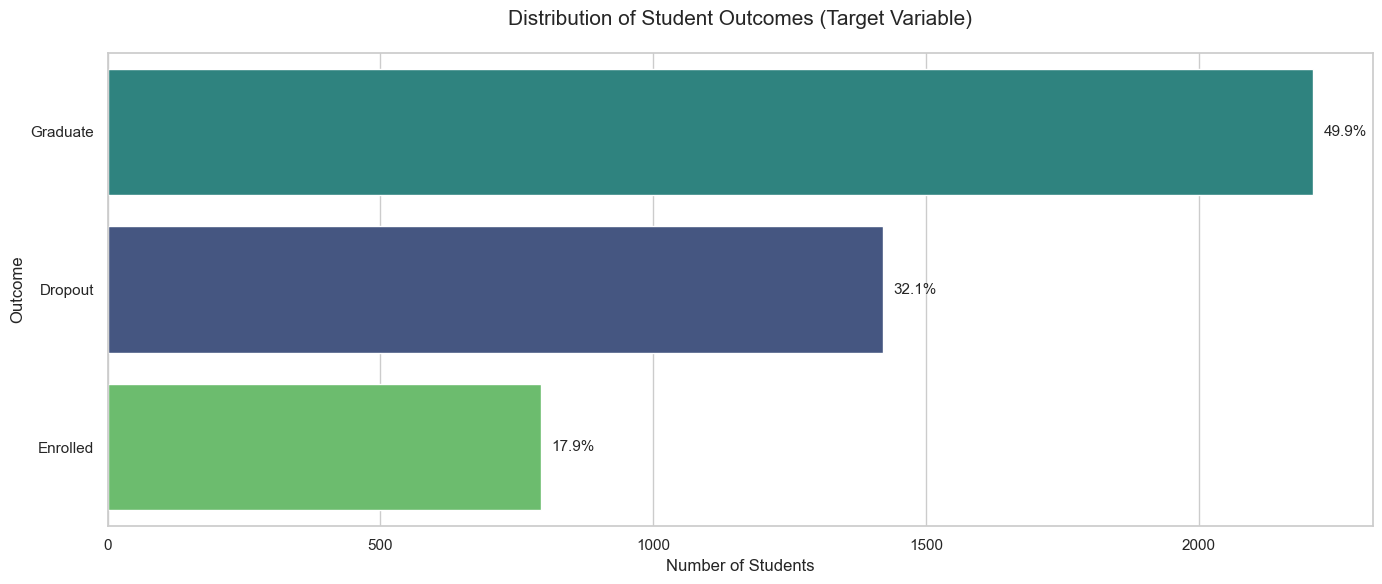

In [5]:

# Create the plot
plt.figure(figsize=(14, 6))
order = df['target'].value_counts().index
ax = sns.countplot(data=df, y='target', order=order, palette='viridis', hue='target')

# Add titles and labels
plt.title('Distribution of Student Outcomes (Target Variable)', fontsize=15, pad=20)
plt.xlabel('Number of Students', fontsize=12)
plt.ylabel('Outcome', fontsize=12)

# Add percentage labels on the bars
total = len(df['target'])
for p in ax.patches:
    percentage = f'{100 * p.get_width() / total:.1f}%'
    x = p.get_width() + 20
    y = p.get_y() + p.get_height() / 2
    ax.annotate(percentage, (x, y), va='center', fontsize=11)

plt.tight_layout()
plt.show()

**Interpretation:** The dataset shows that **49.9%** of students graduated, while **32.1%** dropped out. The "Enrolled" category represents **17.9%** of the students. There is a noticeable class imbalance, but the `Dropout` class, the main interest, is well represented, which is good for training the classification model.

#### 1.2 Grade Distribution

I will plot the distribution of grades across different categories, `cu1_grade`, and `cu2_grade` to see how the grades are distributed among students.

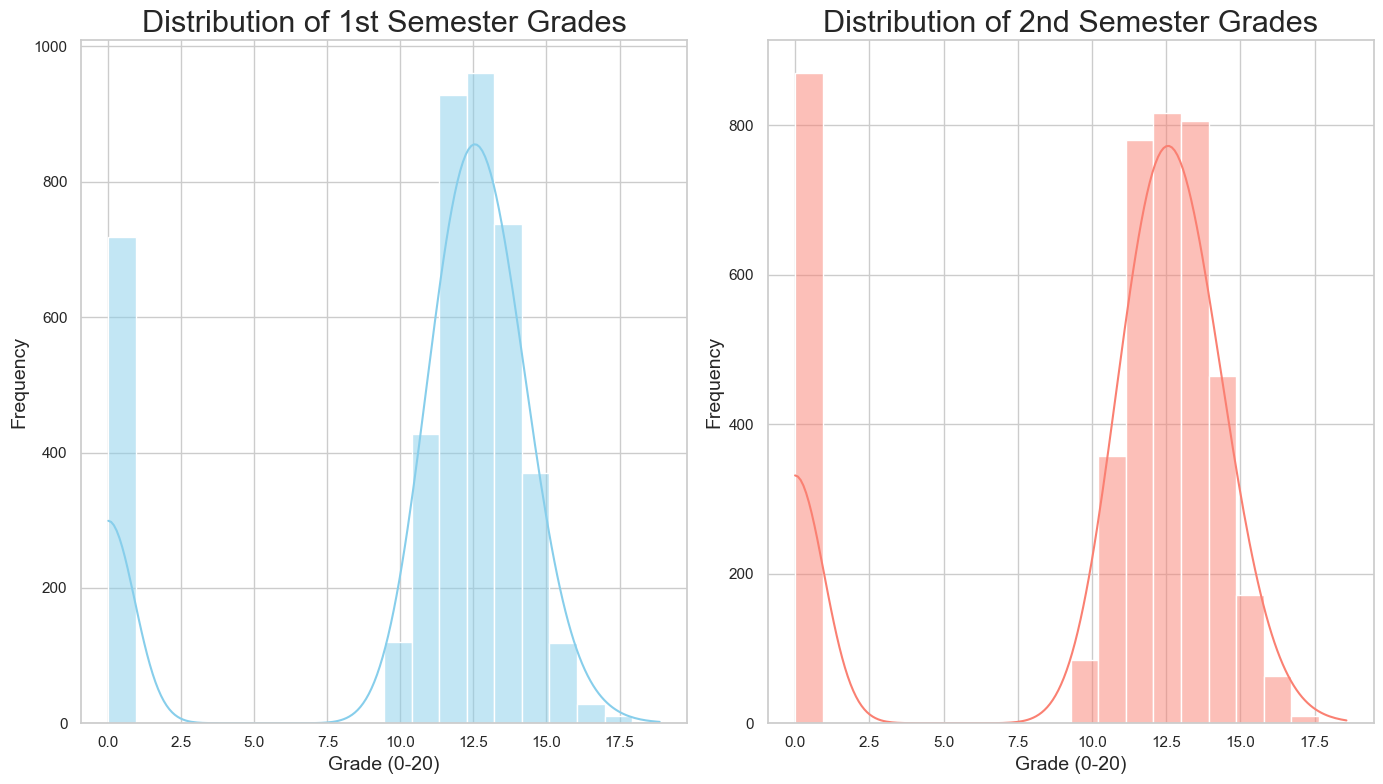

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# plot cu1 grade ( 1st semester grades)
sns.histplot(data=df, x='cu1_grade', kde=True, ax=axes[0], color='skyblue', bins=20)
axes[0].set_title('Distribution of 1st Semester Grades', fontsize=22)
axes[0].set_xlabel('Grade (0-20)', fontsize=14)
axes[0].set_ylabel('Frequency', fontsize=14)

sns.histplot(data=df, x='cu2_grade', kde=True, ax=axes[1], color='salmon', bins=20)
axes[1].set_title('Distribution of 2nd Semester Grades', fontsize=22)
axes[1].set_xlabel('Grade (0-20)', fontsize=14)
axes[1].set_ylabel('Frequency', fontsize=14)

plt.tight_layout()
plt.show()

***Interpretation:*** In the above plot, both semesters show a significant amount of value `0`. This suggests there is a group of students who likely abandoned the courses or failed to attend to exams. In the second semester there is an increase in the number of this group. This is a strong indication of a dropout risk.

For the students who completed the examinations, the grades follow a normal distribution, centered around `12 to 14`. For both semesters, the grades follow a normal distribution.

#### 1.3 Age Distribution

Histogram to visualize age_at_enrollment

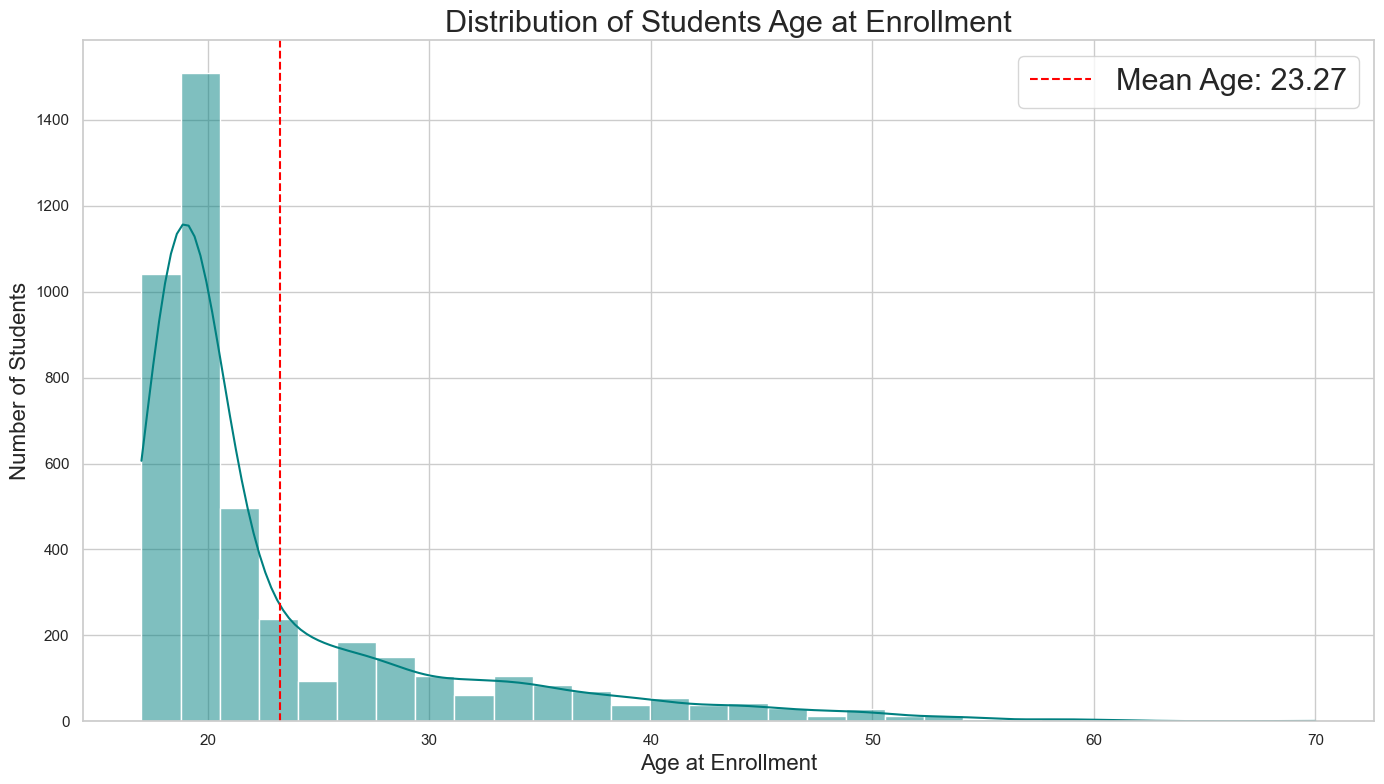

In [7]:
plt.figure(figsize=(14,8))

sns.histplot(data=df, x='age_at_enrollment', kde=True, color='teal', bins=30)

# title
plt.title('Distribution of Students Age at Enrollment', fontsize=22)
plt.xlabel('Age at Enrollment', fontsize=16)
plt.ylabel('Number of Students', fontsize=16)

# line with age mean
plt.axvline(df['age_at_enrollment'].mean(), color='red', linestyle='--', label=f'Mean Age: {df["age_at_enrollment"].mean():.2f}')

plt.legend(fontsize=22)

plt.tight_layout()
plt.show()

***Interaction:*** The distrubution of students age is right skewed with a peak between `18 and 22` years old. This indicates that the majority of students are between 18 and 22 years old, which is typical for university students. The mean age is approximately `23.27` years, which is consistent with the peak in the distribution. The right tail represents mature students up to `60+ age`. These non traditional students often face different challenges like work life balance, financial responsibilities which may correlate with dropout risk compared to younger students. I need to confirm this with theory.

Since the majority of the data is concentrated in early 20s, it may be beneficial to create a new feature called `age_group` during feature engineering, for example `18-21`, `22-25`, `26-30`, and `30+`. These age groups could help the model better capture non linear relationship between age and success.

## 2.0 Bivariate Analysis

#### 2.1 Financial Stress

Financial stress is a significant factor that can impact student success. Students who experience financial stress may struggle to pay for tuition, books, and other expenses, which can lead to academic difficulties and increased dropout rates. In this step, I will plot how `debtor` status and `tuition_fees_up_to_date` relates to the `target` variable`.

This step relates to the Research Question 2, where I try to identify the factors wich causes students dropouts.


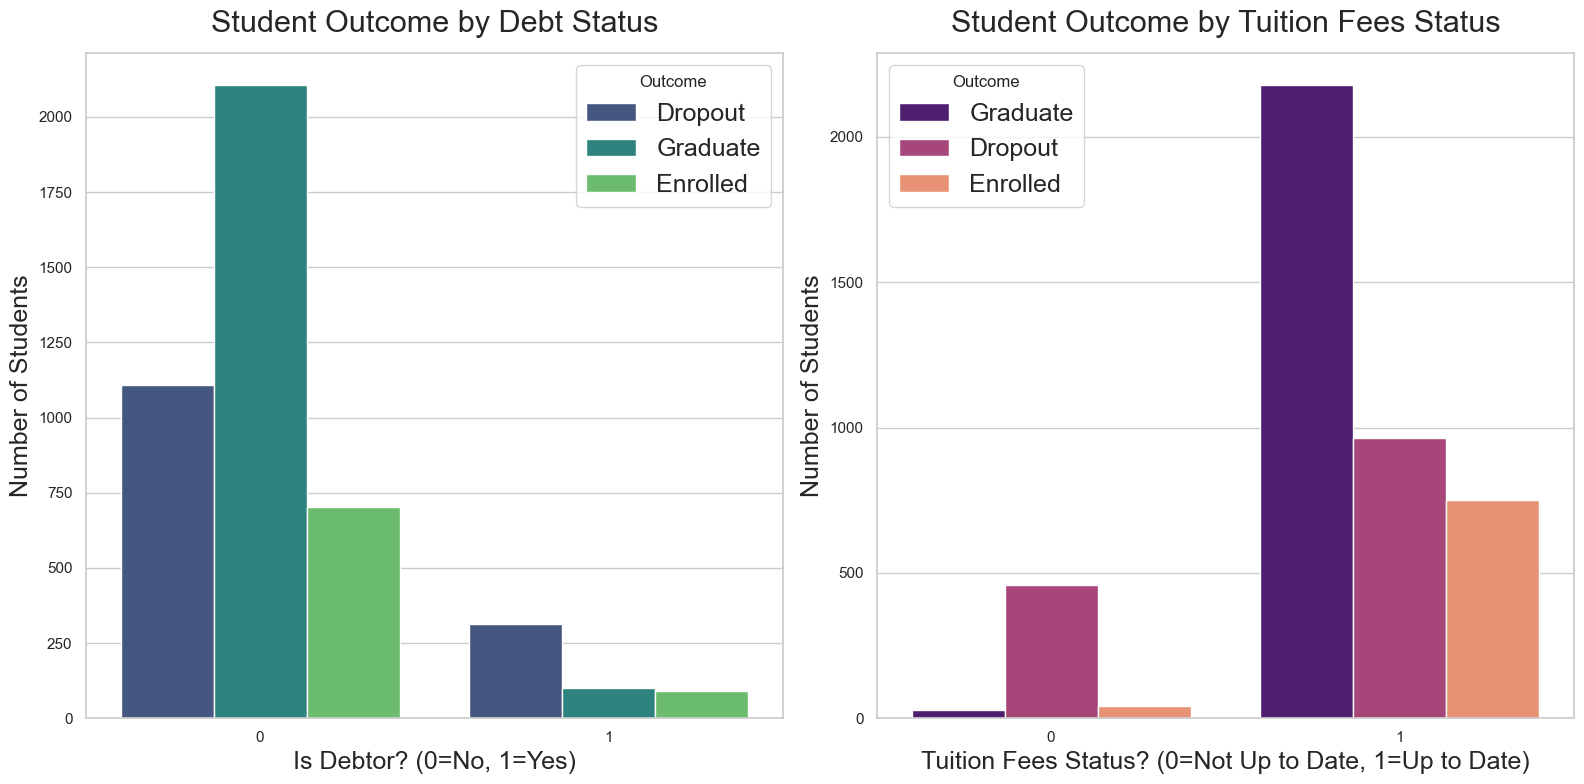

In [8]:
# figure for two plots
fig, axes = plt.subplots(1,2, figsize=(16,8))

# plot 1, student outcome by debt status
sns.countplot(data=df, x='debtor', hue='target', palette='viridis', ax=axes[0])
axes[0].set_title('Student Outcome by Debt Status', fontsize=22, pad=15)

axes[0].set_xlabel('Is Debtor? (0=No, 1=Yes)', fontsize=18)
axes[0].set_ylabel('Number of Students', fontsize=18)
axes[0].legend(title='Outcome', loc='upper right', fontsize=18)

# plot 2: students outcome by tuition fees
sns.countplot(data=df, x='tuition_fees_up_to_date', hue='target', palette='magma', ax=axes[1])
axes[1].set_title('Student Outcome by Tuition Fees Status', fontsize=22, pad=15)
axes[1].set_xlabel('Tuition Fees Status? (0=Not Up to Date, 1=Up to Date)', fontsize=18)
axes[1].set_ylabel('Number of Students', fontsize=18)
axes[1].legend(title='Outcome', loc='upper left', fontsize=18)

plt.tight_layout()
plt.show()


***Interpretation:*** From the plot `Student Outcome by Debt Status` I can see that when `deptor=1` there are a significant number of students with outcome `Dropout`.

From the plot `Student Outcome by Tuition Fees Status` I can see that when `tuition_fees_up_to_date=0`, meaning fees are not up to date, there are a significant number of students with outcome `Dropout`, and a few with outcome `Graduate`.

These finding suggest that financial issues like missing a tuition payment is an indicator that that the outcome may be `Dropout`.

#### 2.2 Academic Success
 
 In this step I will compare the `cu2_approved` (courses approved) with the target variable. I expect to see a correlation between the number of courses approved and the outcome of the student.


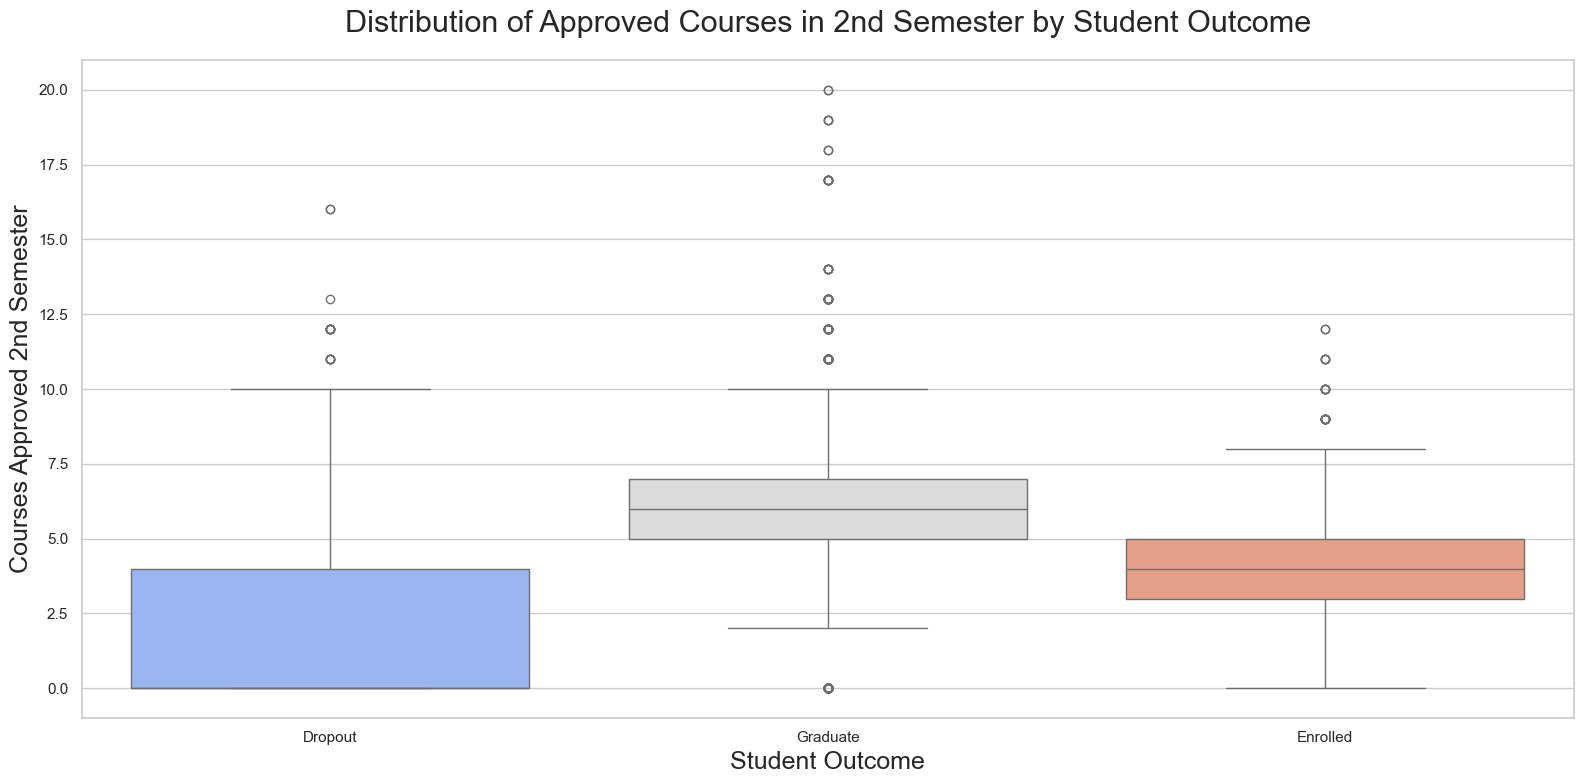

In [9]:
plt.figure(figsize=(16,8))

# plot to compare approved courses with outcome
sns.boxplot(data=df, x='target', y='cu2_approved', palette='coolwarm', hue='target')

plt.title('Distribution of Approved Courses in 2nd Semester by Student Outcome', fontsize=22, pad=20)
plt.xlabel('Student Outcome', fontsize=18)
plt.ylabel('Courses Approved 2nd Semester', fontsize=18)

plt.tight_layout()
plt.show()

***Interpretation:*** As expected, when students have a higher number of courses approved in the second semester, the probability of graduating increases. However, there are still students with a high number of approved courses who drop out, indicating that other factors may also play a role in the outcome.

For `Graduate` the median is about `6` while the `Dropout` is `0` indicating that students who drop out fail to complete courses.

For `Enrolled` students the median is between `2.5 and 5` indicating students that are progressing or at risk of dropping out.

#### 2.3 Scholarship impact

With this visualization I would like to see if scholarships are an effective way to improve student outcomes.

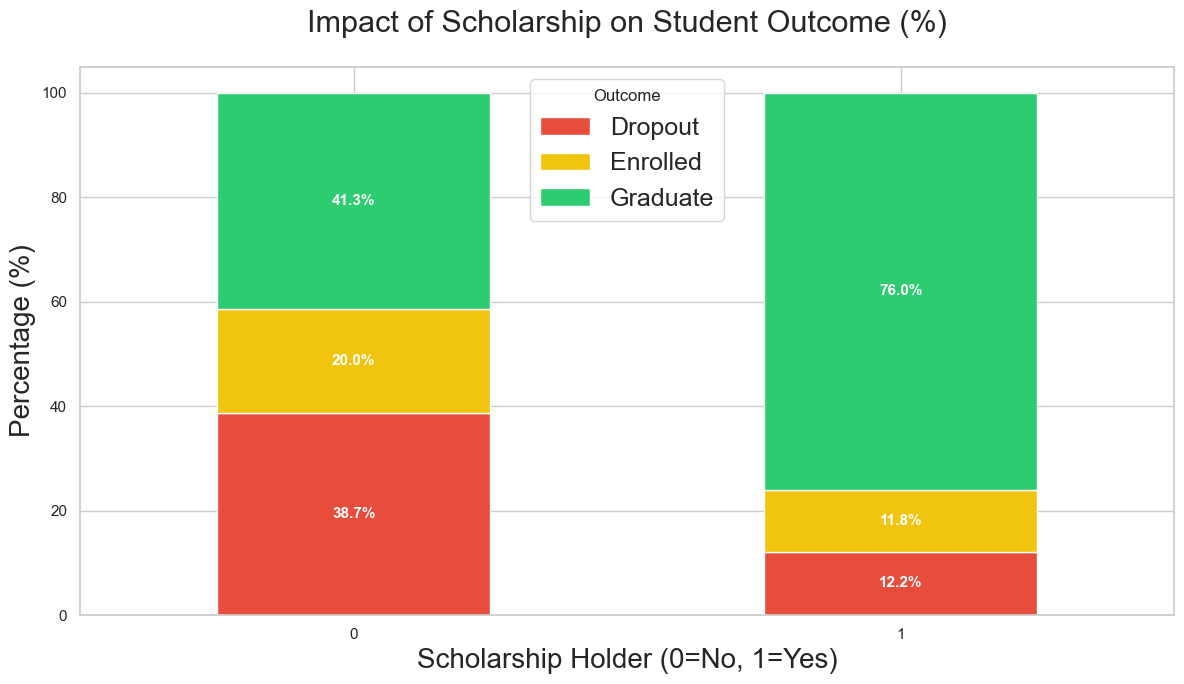

In [10]:
# percentage for each scholarship group
scholarship_counts = df.groupby(['scholarship_holder', 'target']).size().unstack()

scholarship_pct = scholarship_counts.div(scholarship_counts.sum(axis=1), axis=0) * 100

ax = scholarship_pct.plot(kind='bar', stacked=True,figsize=(12, 7), color=['#e74c3c', '#f1c40f', '#2ecc71'])

# plot labels
plt.title('Impact of Scholarship on Student Outcome (%)', fontsize=22, pad = 25)
plt.xlabel('Scholarship Holder (0=No, 1=Yes)', fontsize=20)
plt.xticks(rotation=0)
plt.ylabel('Percentage (%)', fontsize=20)
plt.legend(title='Outcome', fontsize=18, loc='upper center')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0: # Only show labels for non-zero bars
        x, y = p.get_xy()
        ax.annotate(f'{height:.1f}%', (x + width/2, y + height/2), ha='center', va='center', fontsize=11, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

***Interpretation:*** The above plot shows that `scholarship holder=1` have higher gratuation rate, 76%, compared to just 41.3% of those students without a scholarship (`scholarship_holder=0`). This suggests that financial support is a strong predictor of academic competition.

### 2.4 Multivariate Analysis

#### 2.4.1 Grade Progression

In this step I will compare the grades progression by using a scatter plot of `cu1_grade` (first semester) vs `cu2_grade` (second semester) by `target`. The grade scale goes from `0-20`, where `0` represents a failing grade and `20` represents a perfect grade.


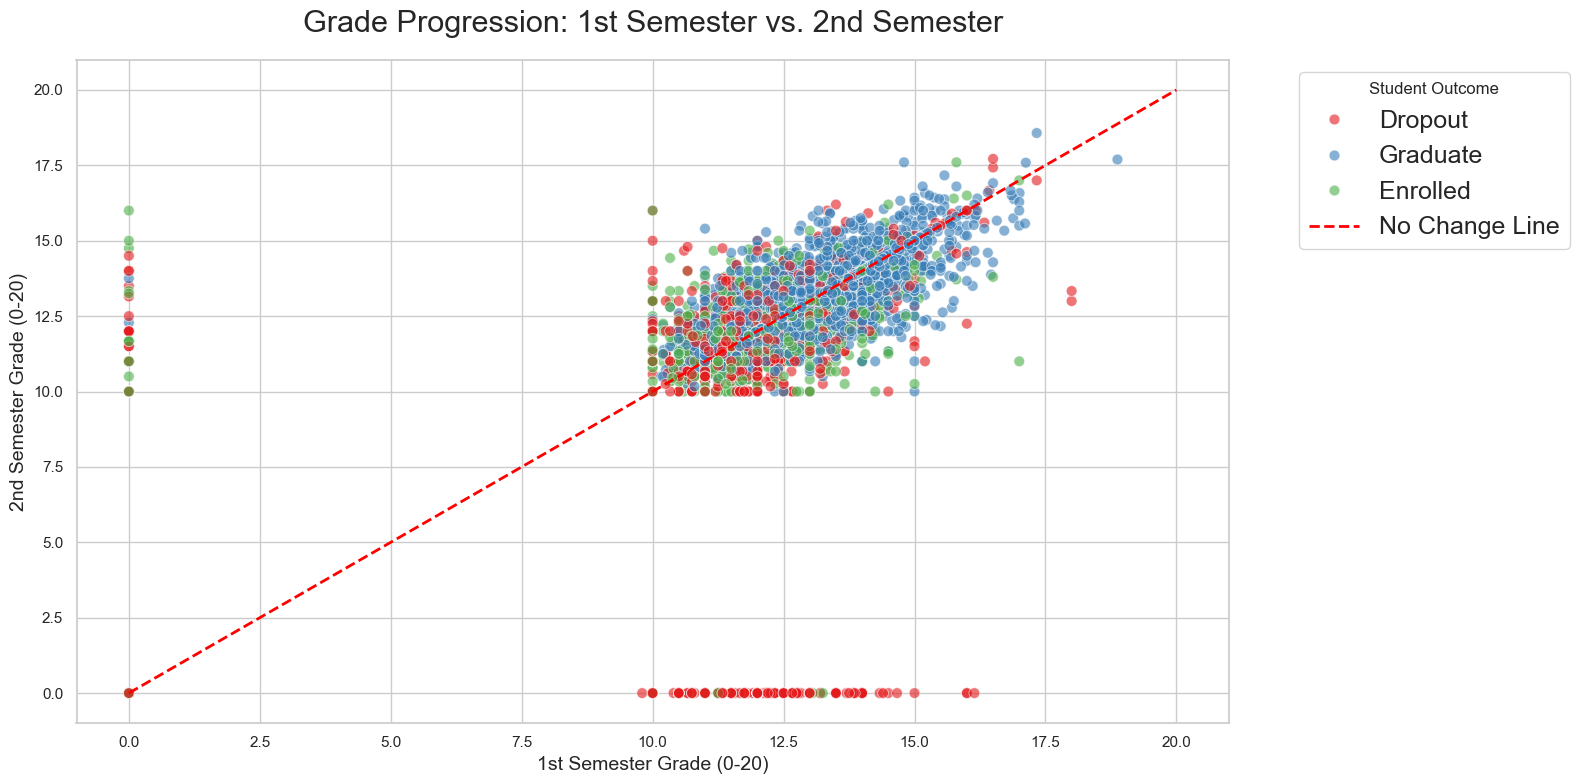

In [11]:
plt.figure(figsize=fig_size)

# scatter plot
sns.scatterplot(data=df, x='cu1_grade', y='cu2_grade', hue='target', palette='Set1', alpha=0.6, s=60)

# add diagonal line
plt.plot([0, 20], [0, 20], color='red', linestyle='--', linewidth=2, label='No Change Line')

# labels and title
plt.title('Grade Progression: 1st Semester vs. 2nd Semester', fontsize=22, pad=20)
plt.xlabel('1st Semester Grade (0-20)', fontsize=14)
plt.ylabel('2nd Semester Grade (0-20)', fontsize=14)
plt.legend(title='Student Outcome', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=18)

plt.tight_layout()
plt.show()

***Interpretation:*** In this plot the graduated students are located at the top right above the red line, this shows students maintained consistent progress from the first to the second semester. At point `(x,y)=(0,0)` there is a concentration of students meaning they never pass the first semester.

The students above the red line indicate and improvement in grades, while those below show a decline in grades. Below the red line there are lots of students with status `Dropout`, this tells me that grade decline is a good predictor for students outcome

#### 2.4.2 Correlation Heatmap

I will try to find any correlation between numerical features in the dataset to identify which factors are most strongly associated with student outcomes. First I would need to preprocess the `target` column to convert it into numberical value. I will map the `target` variable with `{'Graduate': 2, 'Enrolled': 1, 'Dropout': 0}`

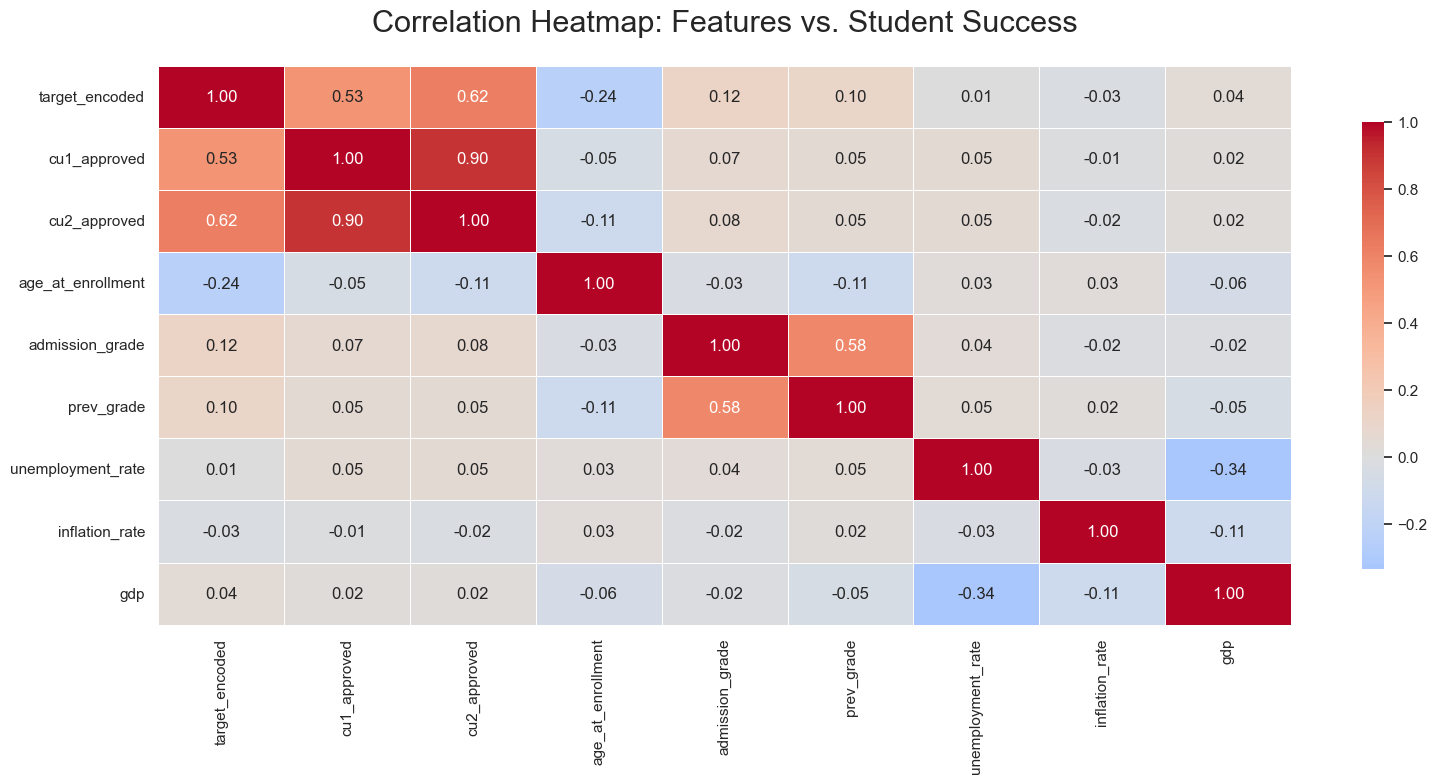

In [12]:
target_map = {'Graduate': 2, 'Enrolled': 1, 'Dropout': 0}
df_copy = df.copy()

df_copy['target_encoded'] = df_copy['target'].map(target_map)

numerical_columns = ['target_encoded', 'cu1_approved', 'cu2_approved', 'age_at_enrollment', 'admission_grade', 'prev_grade', 'unemployment_rate', 'inflation_rate', 'gdp']

corr_matrix = df_copy[numerical_columns].corr()

plt.figure(figsize=fig_size)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',center=0, linewidths=.5, cbar_kws={"shrink": .8})
#labels\
plt.title('Correlation Heatmap: Features vs. Student Success', fontsize=22, pad=25)
plt.tight_layout()
plt.show()

***Interpretation:*** The strongest positive correlations with the `target` variable are `cu2_approved (0.62)` and `cu1_approved (0.58)`. These two features are highly correlated with the target variable, indicating that they have a strong influence on student success. The negative correlation between `age_at_enrollment` and `target` suggests that older students are more likely to dropout. The correlation between `unemployment_rate` and `target` is negative, indicating that higher unemployment rates are associated with higher dropout rates. The correlation between `inflation_rate` and `target` is positive, indicating that higher inflation rates are associated with higher dropout rates. The correlation between `gdp` and `target` is negative, indicating that higher GDP is associated with lower dropout rates.

A high correlation between `cu1_approved` and `cu2_approved` `(0.90)` suggests that students who are approved for both courses are more likely to succeed. This needs to be monitoring during modeling to avoid overfitting.


### 3.0 Feature Engineering

In this section, we will explore different feature engineering techniques to improve the performance of our model. We will start by creating new features from the existing ones, then we will perform feature selection to remove irrelevant or redundant features.


### 3.1 Age-Group Features

From the `age_group_at_enrollment` analysis in step `1.3` I found that it may be beneficial to create a new `age_group` feature. The age group will be `18-21`, `22-25`, `26-30`, and `30+`



### 3.1.1 Age plot by Group

Before creating the new feature, I will plot the groups to see how the group distribution is across the dataset.

<Figure size 1600x800 with 0 Axes>

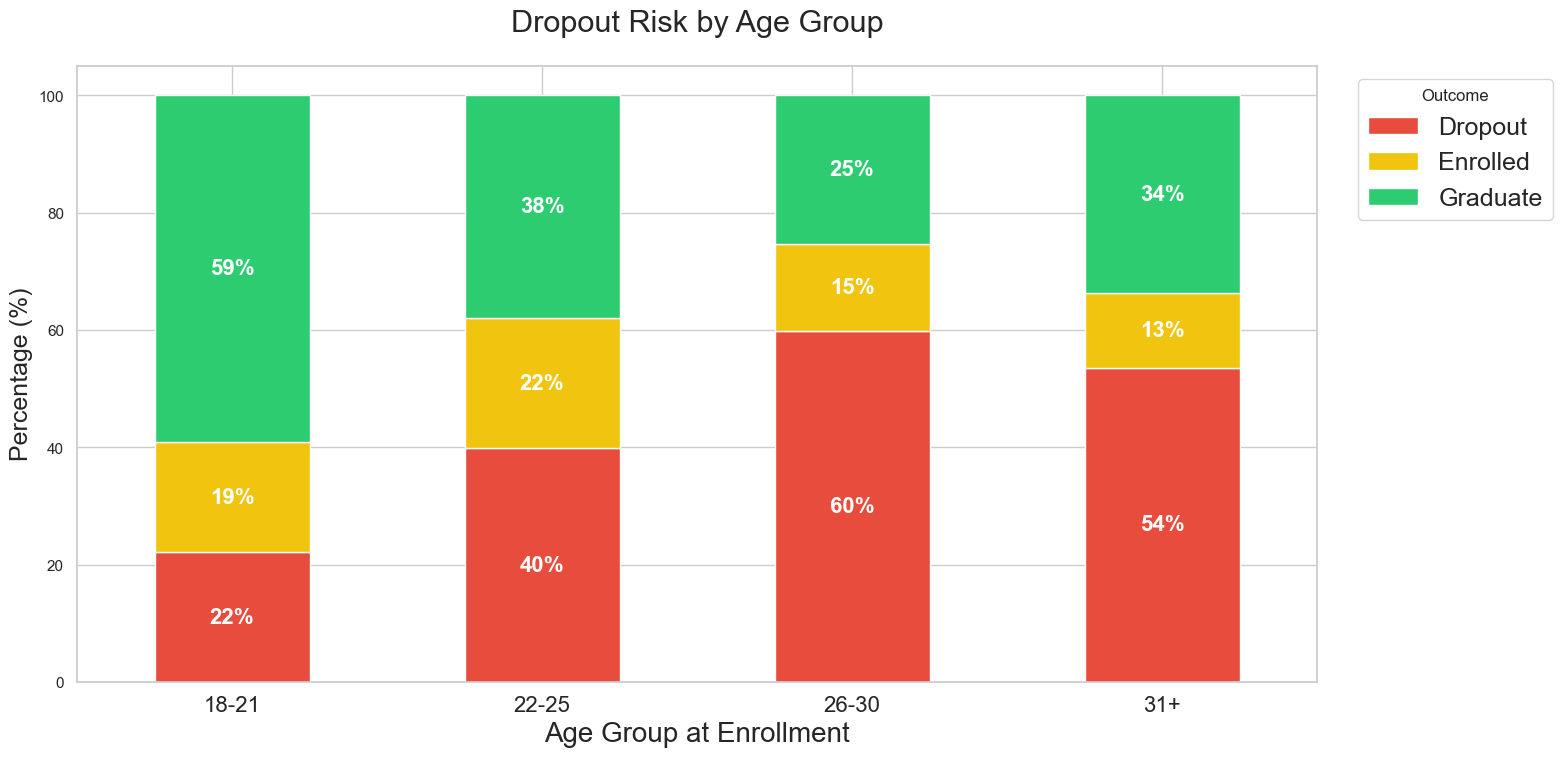

In [44]:
# Age groups
bins = [0,21,25,30,100]
labels = ['18-21', '22-25', '26-30', '31+']
df['age_group'] =  pd.cut(df['age_at_enrollment'], bins=bins, labels=labels)

# plot
plt.figure(figsize=fig_size)
age_target_pct = df.groupby('age_group', observed=True)['target'].value_counts(normalize=True).unstack() * 100

ax = age_target_pct.plot(kind='bar', stacked=True, figsize=fig_size, color=['#e74c3c', '#f1c40f', '#2ecc71'])

# Add percentage labels to each segment
for container in ax.containers:
    labels = [f'{v:.0f}%' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=16,
        color='white',
        fontweight='bold'
    )

#labels
plt.title('Dropout Risk by Age Group', fontsize=22, pad=25)
plt.ylabel('Percentage (%)', fontsize=18)
plt.xlabel('Age Group at Enrollment', fontsize=20)
plt.xticks(rotation=0, fontsize=16)
plt.legend(title='Outcome', bbox_to_anchor=(1.2, 1), fontsize=18)
plt.show()

***Interpretation:*** Students in the `18-21` age group have the highest graduation rate with `59%` and `22%` of `Dropout`.  This confirms students who start university immediatly after high school are most likely to complete their degrees.

For the age group `22-25`, there are is a significant increase in the number of `Dropout` with `40%` and a decrease in `Graduation` with `38%`.  This suggests that students who start university after completing their high school education may face challenges in completing their degrees.

The group `26-30` is the most vulnerable group with `60%` of `Dropout` and only `25%` of `Graduation`. This suggest that students in their late 20s likely face highest pressure that caused dropping out.

For students with age `31+` the `Dropout` decrease to `54%`, and the graduation rate increase to `34%`. This suggests that students over 30 have more stability or motivation to finish their degree compared to the age group `26-30`.

## Analysis of Results and Conclusions

Description of the results obtained and if there are conclusions that can be drawn from them.

The analysis of results must be related to the description of the task.

**Note:** An analysis of results does not necessarily lead to conclusions, but to ideas or proposals for future work


## Proposals and Ideas

From the results obtained, what ideas or proposals can be generated to continue with the project
